In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [18]:
# Load data from CSV files
lucid_df = pd.read_csv('LUCID_Tesi_Result.csv')
mlp_df = pd.read_csv('MLP_Tesi_Result.csv')
rf_df = pd.read_csv('RF_Tesi_Results.csv')

# Add model column to identify each model's data
lucid_df['model'] = 'LUCID'
mlp_df['model'] = 'MLP'
rf_df['model'] = 'Random Forest'

print("Data loaded successfully!")
print(f"LUCID data shape: {lucid_df.shape}")
print(f"MLP data shape: {mlp_df.shape}")
print(f"Random Forest data shape: {rf_df.shape}")

# Display first few rows to understand the data structure
print("\nLUCID data sample:")
print(lucid_df.head())
print("\nMLP data sample:")
print(mlp_df.head())
print("\nRandom Forest data sample:")
print(rf_df.head())

Data loaded successfully!
LUCID data shape: (39, 5)
MLP data shape: (39, 5)
Random Forest data shape: (39, 5)

LUCID data sample:
  attack_type                 dataset  f1_score     fnr  model
0  00-WebDDoS           FLATTEN-PCAPS  0.650000  0.5185  LUCID
1  00-WebDDoS       FRAGMENTED_42_150  0.415013  0.9933  LUCID
2  00-WebDDoS  MANIPULATED-FLATTEN_42  0.163900  0.9091  LUCID
3     01-LDAP           FLATTEN-PCAPS  0.812000  0.3165  LUCID
4     01-LDAP       FRAGMENTED_42_150  0.911935  0.0798  LUCID

MLP data sample:
  attack_type      Dataset  f1_score       fnr model
0  00-WebDDoS     Baseline  1.000000  0.000000   MLP
1  00-WebDDoS  Manipulated  0.642857  0.509091   MLP
2  00-WebDDoS   Fragmented  0.476190  0.679144   MLP
3     01-LDAP     Baseline  0.993631  0.012658   MLP
4     01-LDAP  Manipulated  0.950000  0.005236   MLP

Random Forest data sample:
  attack_type                 dataset  f1_score       fnr          model
0  00-WebDDoS           FLATTEN-PCAPS  0.988004  0.0000

In [20]:
# Normalize dataset names to have consistent categories
# Create mapping for dataset types

def normalize_dataset_name(dataset_name):
    """Normalize dataset names to consistent categories"""
    dataset_name = str(dataset_name).upper()
    
    # Check for MANIPULATED first (since MANIPULATED-FLATTEN_42 contains both terms)
    if 'MANIPULATED' in dataset_name or dataset_name == 'MANIPULATED':
        return 'Manipulated'
    elif 'FRAGMENTED' in dataset_name or dataset_name == 'FRAGMENTED':
        return 'Fragmented'
    elif 'FLATTEN' in dataset_name or dataset_name == 'BASELINE':
        return 'Baseline'
    else:
        return dataset_name

# Apply normalization to all dataframes
lucid_df['dataset_type'] = lucid_df['original_dataset'].apply(normalize_dataset_name)
mlp_df['dataset_type'] = mlp_df['original_dataset'].apply(normalize_dataset_name)  
rf_df['dataset_type'] = rf_df['original_dataset'].apply(normalize_dataset_name)

print("Dataset normalization completed!")
print("\nUnique dataset types:")
print("LUCID:", sorted(lucid_df['dataset_type'].unique()))
print("MLP:", sorted(mlp_df['dataset_type'].unique()))
print("RF:", sorted(rf_df['dataset_type'].unique()))

# Check specific mappings
print("\nLUCID dataset mappings:")
print(lucid_df[['original_dataset', 'dataset_type']].drop_duplicates().sort_values('dataset_type'))
print("\nMLP dataset mappings:")
print(mlp_df[['original_dataset', 'dataset_type']].drop_duplicates().sort_values('dataset_type'))
print("\nRF dataset mappings:")
print(rf_df[['original_dataset', 'dataset_type']].drop_duplicates().sort_values('dataset_type'))

Dataset normalization completed!

Unique dataset types:
LUCID: ['Baseline', 'Fragmented', 'Manipulated']
MLP: ['Baseline', 'Fragmented', 'Manipulated']
RF: ['Baseline', 'Fragmented', 'Manipulated']

LUCID dataset mappings:
         original_dataset dataset_type
0           FLATTEN-PCAPS     Baseline
1       FRAGMENTED_42_150   Fragmented
2  MANIPULATED-FLATTEN_42  Manipulated

MLP dataset mappings:
  original_dataset dataset_type
0         Baseline     Baseline
2       Fragmented   Fragmented
1      Manipulated  Manipulated

RF dataset mappings:
         original_dataset dataset_type
0           FLATTEN-PCAPS     Baseline
2       FRAGMENTED_42_150   Fragmented
1  MANIPULATED-FLATTEN_42  Manipulated


In [21]:
# Combine all dataframes
combined_df = pd.concat([
    lucid_df[['attack_type', 'dataset_type', 'fnr', 'f1_score', 'model']],
    mlp_df[['attack_type', 'dataset_type', 'fnr', 'f1_score', 'model']],
    rf_df[['attack_type', 'dataset_type', 'fnr', 'f1_score', 'model']]
], ignore_index=True)

print(f"Combined dataframe shape: {combined_df.shape}")
print("\nDataset types available:", combined_df['dataset_type'].unique())
print("Models available:", combined_df['model'].unique())
print("Attack types available:", sorted(combined_df['attack_type'].unique()))

# Check for any missing values
print(f"\nMissing values: {combined_df.isnull().sum().sum()}")

# Display sample of combined data
print("\nCombined data sample:")
print(combined_df.head(10))

Combined dataframe shape: (117, 5)

Dataset types available: ['Baseline' 'Fragmented' 'Manipulated']
Models available: ['LUCID' 'MLP' 'Random Forest']
Attack types available: ['00-WebDDoS', '01-LDAP', '02-Portmap', '03-DNS', '04-UDPLag', '05-NTP', '06-SNMP', '07-SSDP', '08-Syn', '09-TFTP', '10-UDP', '11-NetBIOS', '12-MSSQL']

Missing values: 0

Combined data sample:
  attack_type dataset_type     fnr  f1_score  model
0  00-WebDDoS     Baseline  0.5185  0.650000  LUCID
1  00-WebDDoS   Fragmented  0.9933  0.415013  LUCID
2  00-WebDDoS  Manipulated  0.9091  0.163900  LUCID
3     01-LDAP     Baseline  0.3165  0.812000  LUCID
4     01-LDAP   Fragmented  0.0798  0.911935  LUCID
5     01-LDAP  Manipulated  0.1675  0.868900  LUCID
6  02-Portmap     Baseline  0.0833  0.916700  LUCID
7  02-Portmap   Fragmented  0.1356  0.912910  LUCID
8  02-Portmap  Manipulated  0.1657  0.879200  LUCID
9      03-DNS     Baseline  0.4595  0.701800  LUCID


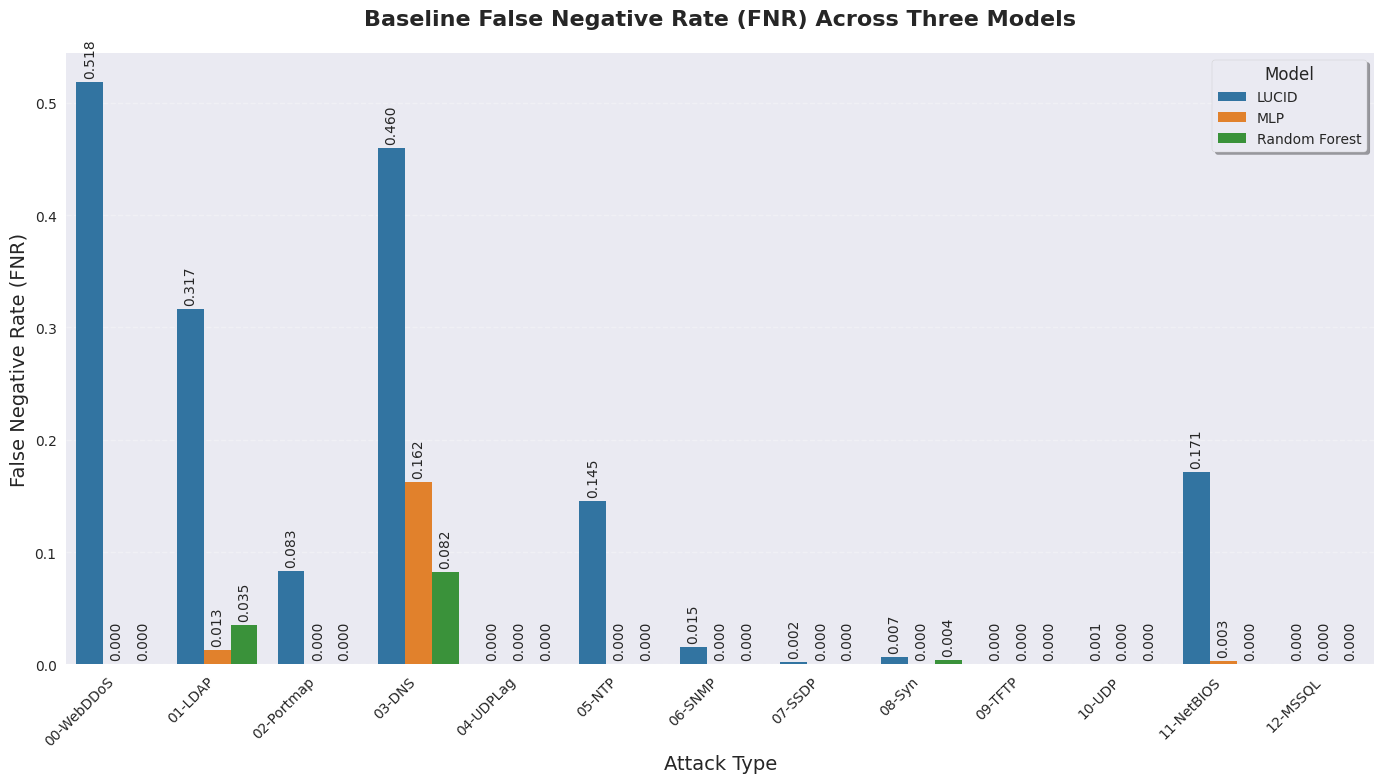

Baseline FNR Statistics:
                 mean     std  min     max
model                                     
LUCID          0.1323  0.1850  0.0  0.5185
MLP            0.0137  0.0448  0.0  0.1622
Random Forest  0.0093  0.0239  0.0  0.0822


In [22]:
# Plot 1: Baseline FNR across three models
baseline_data = combined_df[combined_df['dataset_type'] == 'Baseline'].copy()

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=baseline_data, x='attack_type', y='fnr', hue='model', 
                 palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Baseline False Negative Rate (FNR) Across Three Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Attack Type', fontsize=14)
plt.ylabel('False Negative Rate (FNR)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', loc='upper right', frameon=True, fancybox=True, shadow=True)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', rotation=90, padding=3, fontsize=10)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print baseline statistics
print("Baseline FNR Statistics:")
baseline_stats = baseline_data.groupby('model')['fnr'].agg(['mean', 'std', 'min', 'max']).round(4)
print(baseline_stats)

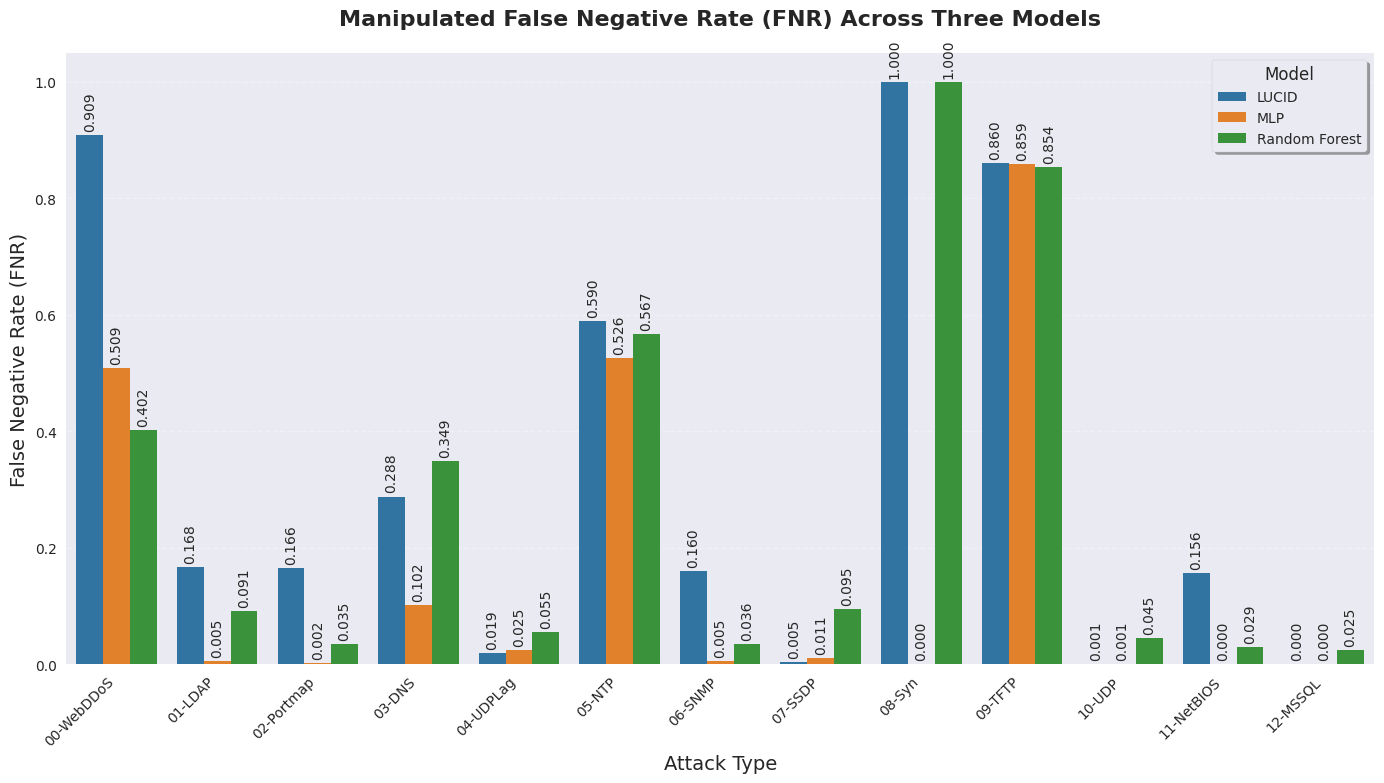

Manipulated FNR Statistics:
                 mean     std     min     max
model                                        
LUCID          0.3324  0.3727  0.0000  1.0000
MLP            0.1574  0.2833  0.0000  0.8594
Random Forest  0.2757  0.3383  0.0246  1.0000


In [23]:
# Plot 2: Manipulated FNR across three models
manipulated_data = combined_df[combined_df['dataset_type'] == 'Manipulated'].copy()

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=manipulated_data, x='attack_type', y='fnr', hue='model',
                 palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Manipulated False Negative Rate (FNR) Across Three Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Attack Type', fontsize=14)
plt.ylabel('False Negative Rate (FNR)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', loc='upper right', frameon=True, fancybox=True, shadow=True)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', rotation=90, padding=3, fontsize=10)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print manipulated statistics
print("Manipulated FNR Statistics:")
manipulated_stats = manipulated_data.groupby('model')['fnr'].agg(['mean', 'std', 'min', 'max']).round(4)
print(manipulated_stats)

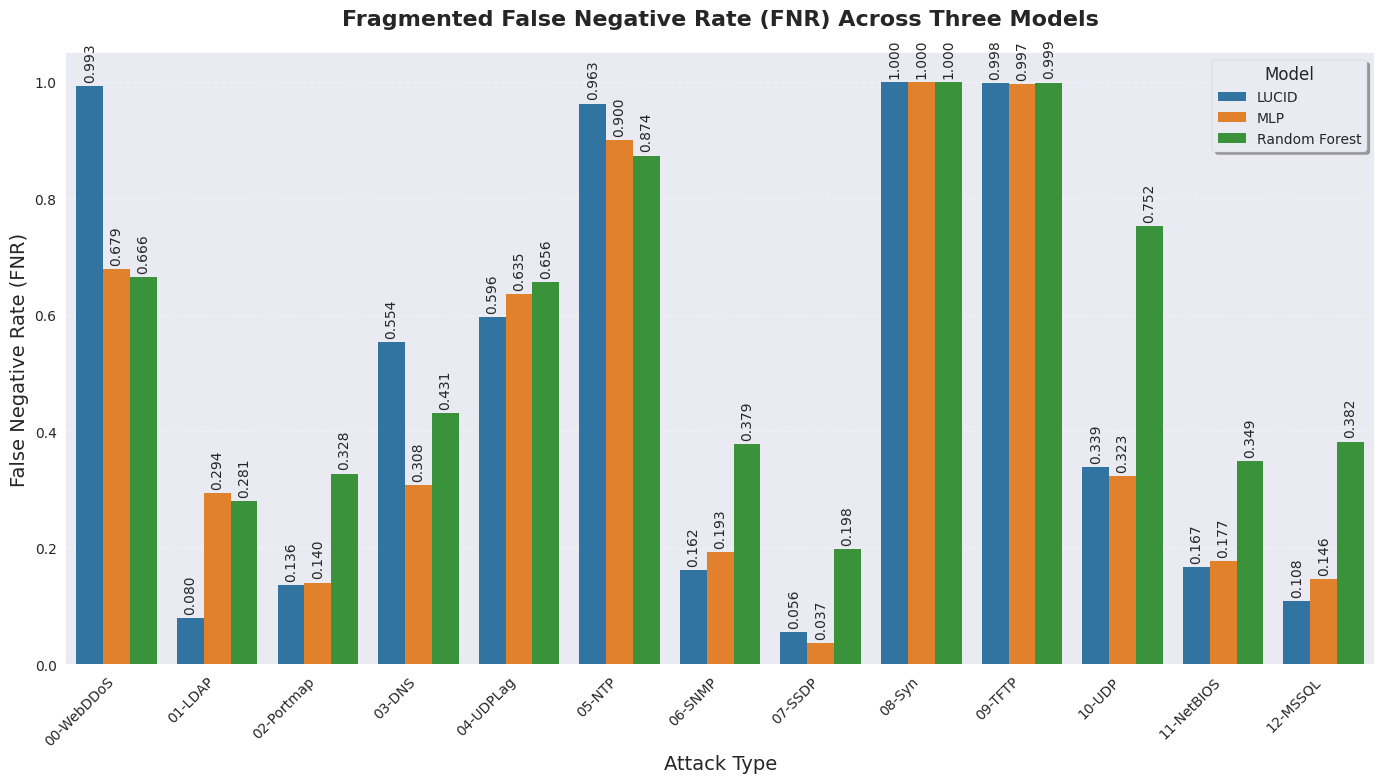

Fragmented FNR Statistics:
                 mean     std     min     max
model                                        
LUCID          0.4731  0.3948  0.0556  0.9999
MLP            0.4484  0.3476  0.0370  0.9999
Random Forest  0.5610  0.2784  0.1976  0.9999


In [24]:
# Plot 3: Fragmented FNR across three models
fragmented_data = combined_df[combined_df['dataset_type'] == 'Fragmented'].copy()

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=fragmented_data, x='attack_type', y='fnr', hue='model',
                 palette=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Fragmented False Negative Rate (FNR) Across Three Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Attack Type', fontsize=14)
plt.ylabel('False Negative Rate (FNR)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', loc='upper right', frameon=True, fancybox=True, shadow=True)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', rotation=90, padding=3, fontsize=10)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print fragmented statistics
print("Fragmented FNR Statistics:")
fragmented_stats = fragmented_data.groupby('model')['fnr'].agg(['mean', 'std', 'min', 'max']).round(4)
print(fragmented_stats)

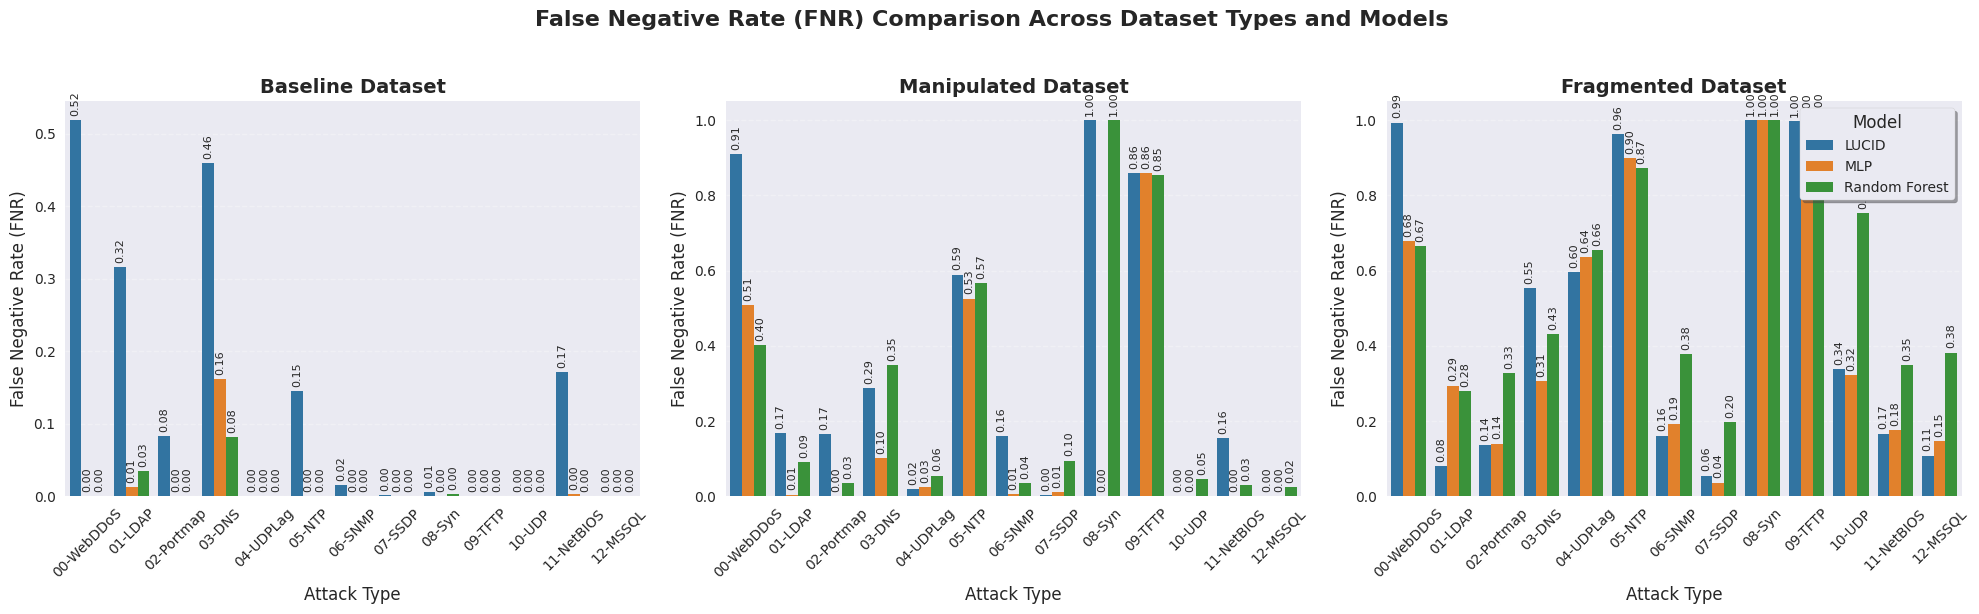

In [25]:
# Comprehensive comparison plot: All dataset types side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('False Negative Rate (FNR) Comparison Across Dataset Types and Models', 
             fontsize=16, fontweight='bold', y=1.02)

dataset_types = ['Baseline', 'Manipulated', 'Fragmented']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, dataset_type in enumerate(dataset_types):
    data_subset = combined_df[combined_df['dataset_type'] == dataset_type].copy()
    
    ax = sns.barplot(data=data_subset, x='attack_type', y='fnr', hue='model', 
                     palette=colors, ax=axes[i])
    
    axes[i].set_title(f'{dataset_type} Dataset', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Attack Type', fontsize=12)
    axes[i].set_ylabel('False Negative Rate (FNR)', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', rotation=90, padding=3, fontsize=8)
    
    # Only show legend on the last subplot
    if i < len(dataset_types) - 1:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Model', loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

In [26]:
# Summary Analysis
print("="*80)
print("SUMMARY ANALYSIS: False Negative Rate (FNR) Across Models and Dataset Types")
print("="*80)

# Overall statistics by model and dataset type
summary_stats = combined_df.groupby(['model', 'dataset_type'])['fnr'].agg(['mean', 'std']).round(4)
print("\nMean FNR by Model and Dataset Type:")
print(summary_stats)

# Best performing model for each dataset type
print("\n" + "="*50)
print("BEST PERFORMING MODELS (Lowest Mean FNR):")
print("="*50)

for dataset_type in ['Baseline', 'Manipulated', 'Fragmented']:
    subset = combined_df[combined_df['dataset_type'] == dataset_type]
    best_model = subset.groupby('model')['fnr'].mean().idxmin()
    best_fnr = subset.groupby('model')['fnr'].mean().min()
    
    print(f"{dataset_type:12}: {best_model:15} (Mean FNR: {best_fnr:.4f})")

# Model robustness across dataset types
print("\n" + "="*50)
print("MODEL ROBUSTNESS ANALYSIS:")
print("="*50)

model_robustness = combined_df.groupby('model')['fnr'].agg(['mean', 'std', 'max']).round(4)
print("Overall performance across all dataset types:")
print(model_robustness)

# Calculate degradation from baseline
print("\n" + "="*50)
print("PERFORMANCE DEGRADATION FROM BASELINE:")
print("="*50)

baseline_means = combined_df[combined_df['dataset_type'] == 'Baseline'].groupby('model')['fnr'].mean()
manipulated_means = combined_df[combined_df['dataset_type'] == 'Manipulated'].groupby('model')['fnr'].mean()
fragmented_means = combined_df[combined_df['dataset_type'] == 'Fragmented'].groupby('model')['fnr'].mean()

for model in baseline_means.index:
    baseline_fnr = baseline_means[model]
    manipulated_fnr = manipulated_means.get(model, np.nan)
    fragmented_fnr = fragmented_means.get(model, np.nan)
    
    print(f"\n{model}:")
    print(f"  Baseline FNR:    {baseline_fnr:.4f}")
    if not np.isnan(manipulated_fnr):
        degradation = ((manipulated_fnr - baseline_fnr) / baseline_fnr * 100) if baseline_fnr > 0 else float('inf')
        print(f"  Manipulated FNR: {manipulated_fnr:.4f} ({degradation:+.1f}% change)")
    if not np.isnan(fragmented_fnr):
        degradation = ((fragmented_fnr - baseline_fnr) / baseline_fnr * 100) if baseline_fnr > 0 else float('inf')
        print(f"  Fragmented FNR:  {fragmented_fnr:.4f} ({degradation:+.1f}% change)")

SUMMARY ANALYSIS: False Negative Rate (FNR) Across Models and Dataset Types

Mean FNR by Model and Dataset Type:
                              mean     std
model         dataset_type                
LUCID         Baseline      0.1323  0.1850
              Fragmented    0.4731  0.3948
              Manipulated   0.3324  0.3727
MLP           Baseline      0.0137  0.0448
              Fragmented    0.4484  0.3476
              Manipulated   0.1574  0.2833
Random Forest Baseline      0.0093  0.0239
              Fragmented    0.5610  0.2784
              Manipulated   0.2757  0.3383

BEST PERFORMING MODELS (Lowest Mean FNR):
Baseline    : Random Forest   (Mean FNR: 0.0093)
Manipulated : MLP             (Mean FNR: 0.1574)
Fragmented  : MLP             (Mean FNR: 0.4484)

MODEL ROBUSTNESS ANALYSIS:
Overall performance across all dataset types:
                 mean     std     max
model                                
LUCID          0.3126  0.3521  1.0000
MLP            0.2065  0.3126  0.999

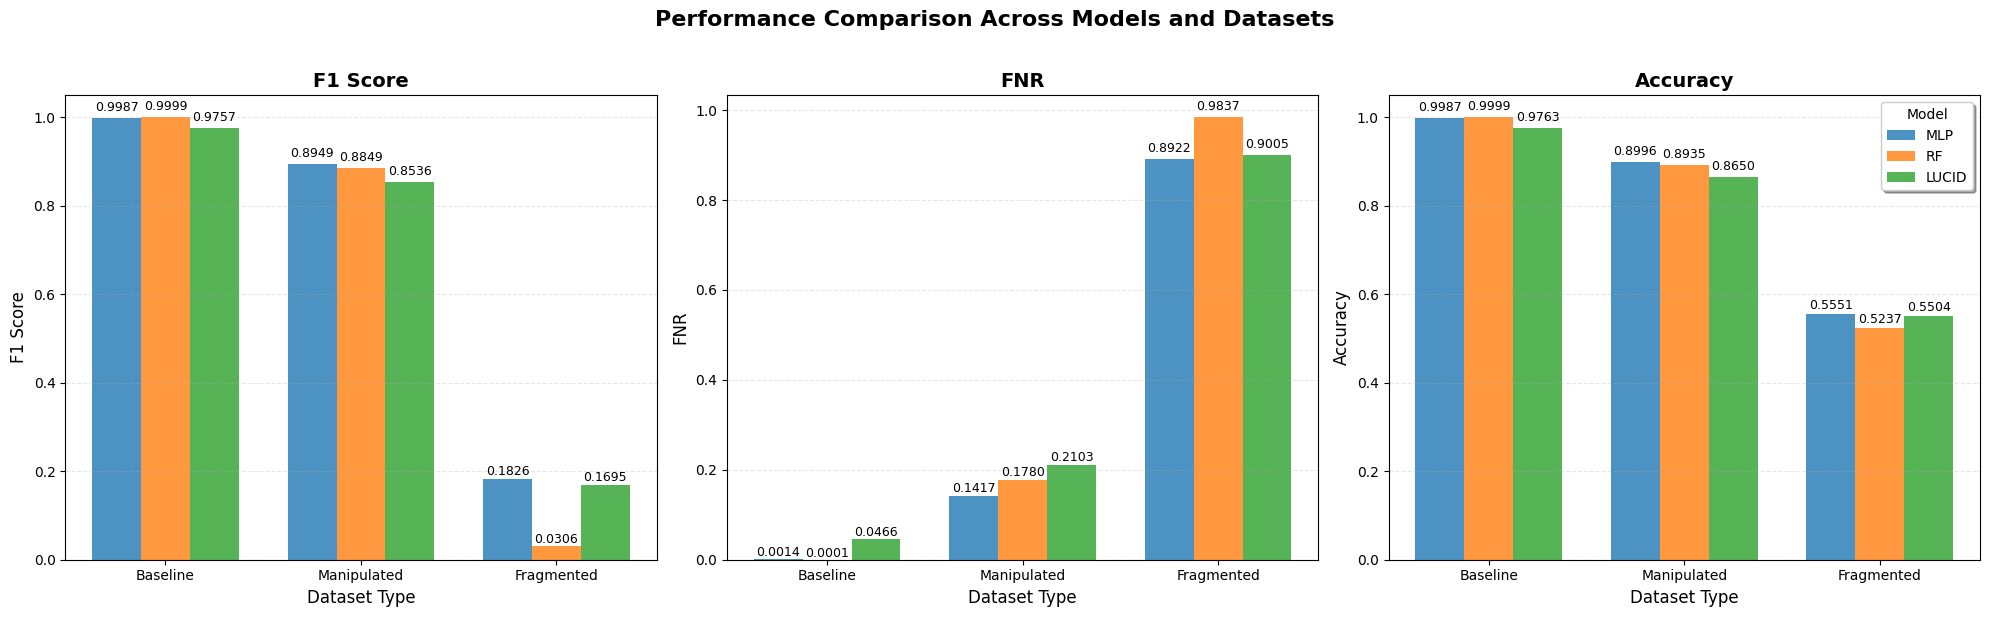

PERFORMANCE METRICS SUMMARY

F1 Score:
----------------------------------------
Model         LUCID     MLP      RF
Dataset                            
Baseline     0.9757  0.9987  0.9999
Fragmented   0.1695  0.1826  0.0306
Manipulated  0.8536  0.8949  0.8849

Best performing model by dataset (lowest F1_Score for FNR, highest for others):
  Baseline: RF (0.9999)
  Manipulated: MLP (0.8949)
  Fragmented: MLP (0.1826)

FNR:
----------------------------------------
Model         LUCID     MLP      RF
Dataset                            
Baseline     0.0466  0.0014  0.0001
Fragmented   0.9005  0.8922  0.9837
Manipulated  0.2103  0.1417  0.1780

Best performing model by dataset (lowest FNR for FNR, highest for others):
  Baseline: RF (0.0001)
  Manipulated: MLP (0.1417)
  Fragmented: MLP (0.8922)

Accuracy:
----------------------------------------
Model         LUCID     MLP      RF
Dataset                            
Baseline     0.9763  0.9987  0.9999
Fragmented   0.5504  0.5551  0.5237
Ma

In [6]:
# Create comprehensive comparison plot with the new data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the data
data = {
    'Dataset': ['Baseline', 'Baseline', 'Baseline', 'Manipulated', 'Manipulated', 'Manipulated', 
                'Fragmented', 'Fragmented', 'Fragmented'],
    'Model': ['MLP', 'RF', 'LUCID', 'MLP', 'RF', 'LUCID', 'MLP', 'RF', 'LUCID'],
    'F1_Score': [0.9987, 0.9999, 0.9757, 0.8949, 0.8849, 0.8536, 0.1826, 0.0306, 0.1695],
    'FNR': [0.0014, 0.0001, 0.0466, 0.1417, 0.1780, 0.2103, 0.8922, 0.9837, 0.9005],
    'Accuracy': [0.9987, 0.9999, 0.9763, 0.8996, 0.8935, 0.8650, 0.5551, 0.5237, 0.5504]
}

# Create DataFrame
comparison_df = pd.DataFrame(data)

# Set up the plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Performance Comparison Across Models and Datasets', fontsize=16, fontweight='bold', y=1.02)

# Define colors for models
model_colors = {'MLP': '#1f77b4', 'RF': '#ff7f0e', 'LUCID': '#2ca02c'}
datasets = ['Baseline', 'Manipulated', 'Fragmented']
models = ['MLP', 'RF', 'LUCID']
metrics = ['F1_Score', 'FNR', 'Accuracy']
metric_titles = ['F1 Score', 'FNR', 'Accuracy']

# Create bar plots for each metric
for i, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[i]
    
    # Prepare data for grouped bar chart
    x = np.arange(len(datasets))
    width = 0.25
    
    # Plot bars for each model
    for j, model in enumerate(models):
        values = []
        for dataset in datasets:
            value = comparison_df[(comparison_df['Dataset'] == dataset) & 
                                (comparison_df['Model'] == model)][metric].iloc[0]
            values.append(value)
        
        bars = ax.bar(x + j*width, values, width, label=model, color=model_colors[model], alpha=0.8)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontsize=9, rotation=0)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Dataset Type', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_xticks(x + width)
    ax.set_xticklabels(datasets)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Only show legend on the last subplot
    if i == len(metrics) - 1:
        ax.legend(title='Model', loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*80)
print("PERFORMANCE METRICS SUMMARY")
print("="*80)

for metric, title in zip(metrics, metric_titles):
    print(f"\n{title}:")
    print("-" * 40)
    pivot_table = comparison_df.pivot(index='Dataset', columns='Model', values=metric)
    print(pivot_table.round(4))
    
    # Find best performing model for each dataset
    print(f"\nBest performing model by dataset (lowest {metric} for FNR, highest for others):")
    for dataset in datasets:
        dataset_data = pivot_table.loc[dataset]
        if metric == 'FNR':  # Lower is better for FNR
            best_model = dataset_data.idxmin()
            best_value = dataset_data.min()
        else:  # Higher is better for F1 Score and Accuracy
            best_model = dataset_data.idxmax()
            best_value = dataset_data.max()
        print(f"  {dataset}: {best_model} ({best_value:.4f})")

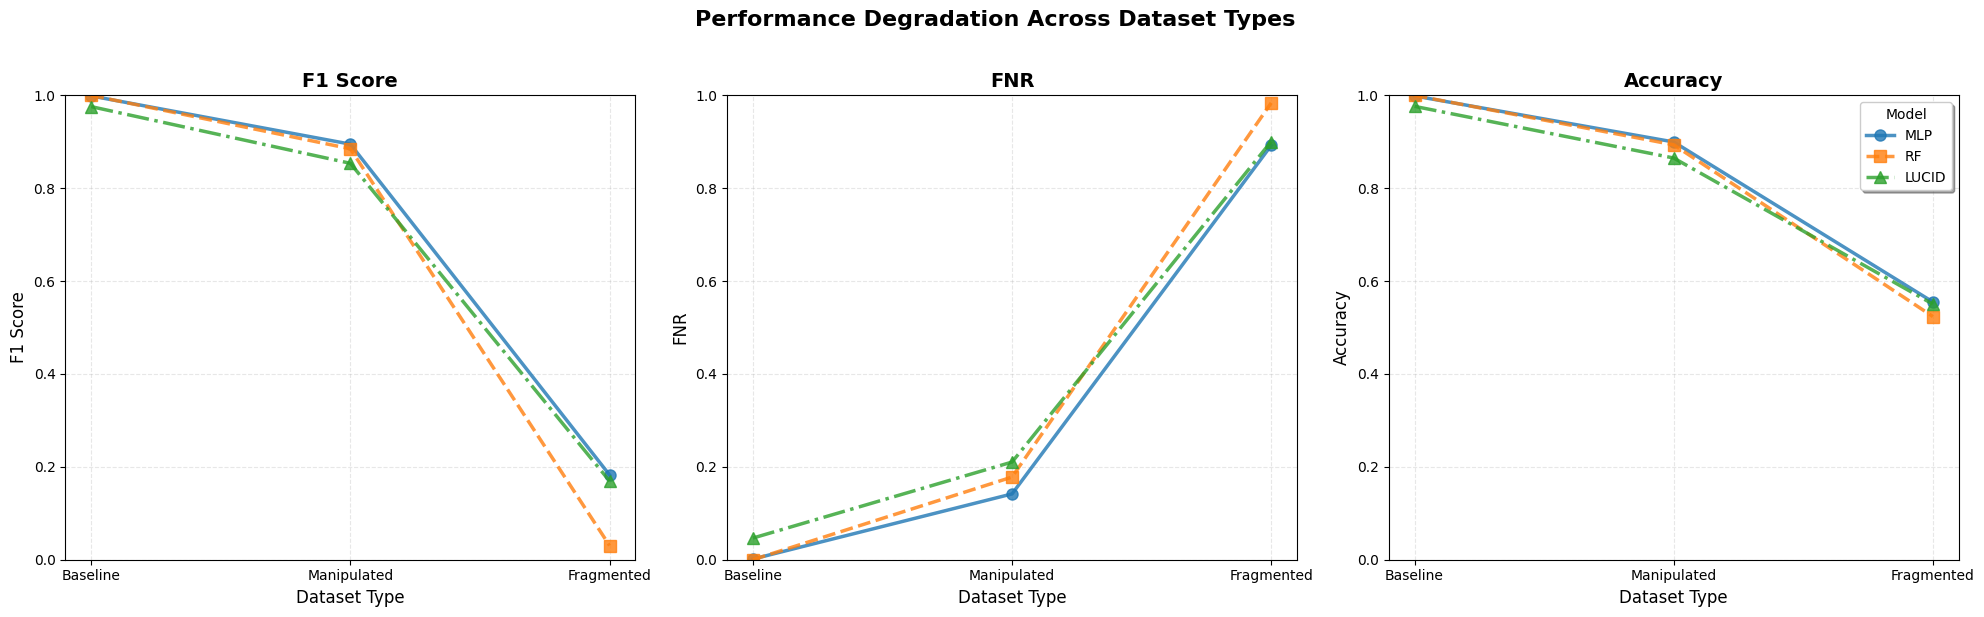

PERFORMANCE DEGRADATION ANALYSIS

F1 Score - Progressive Degradation:
--------------------------------------------------

  MLP:
    Baseline → Manipulated: 0.9987 → 0.8949 (-10.4%)
    Baseline → Fragmented:  0.9987 → 0.1826 (-81.7%)
    Total degradation: -81.7%

  RF:
    Baseline → Manipulated: 0.9999 → 0.8849 (-11.5%)
    Baseline → Fragmented:  0.9999 → 0.0306 (-96.9%)
    Total degradation: -96.9%

  LUCID:
    Baseline → Manipulated: 0.9757 → 0.8536 (-12.5%)
    Baseline → Fragmented:  0.9757 → 0.1695 (-82.6%)
    Total degradation: -82.6%

FNR - Progressive Degradation:
--------------------------------------------------

  MLP:
    Baseline → Manipulated: 0.0014 → 0.1417 (+10021.4%)
    Baseline → Fragmented:  0.0014 → 0.8922 (+63628.6%)
    Total degradation: +63628.6%

  RF:
    Baseline → Manipulated: 0.0001 → 0.1780 (+177900.0%)
    Baseline → Fragmented:  0.0001 → 0.9837 (+983600.0%)
    Total degradation: +983600.0%

  LUCID:
    Baseline → Manipulated: 0.0466 → 0.2103 (

In [8]:
# Line plot version to better visualize progressive degradation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Performance Degradation Across Dataset Types', fontsize=16, fontweight='bold', y=1.02)

# Define markers for each model to distinguish lines
model_markers = {'MLP': 'o', 'RF': 's', 'LUCID': '^'}
model_linestyles = {'MLP': '-', 'RF': '--', 'LUCID': '-.'}

# Create line plots for each metric
for i, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[i]
    
    # Plot lines for each model
    for model in models:
        values = []
        for dataset in datasets:
            value = comparison_df[(comparison_df['Dataset'] == dataset) & 
                                (comparison_df['Model'] == model)][metric].iloc[0]
            values.append(value)
        
        # Plot line with markers
        line = ax.plot(datasets, values, 
                      color=model_colors[model], 
                      marker=model_markers[model], 
                      linestyle=model_linestyles[model],
                      linewidth=2.5, 
                      markersize=8, 
                      label=model,
                      alpha=0.8)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Dataset Type', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Set y-axis limits to better show the degradation
    if metric == 'FNR':
        ax.set_ylim(0, 1)  # FNR ranges from 0 to 1
    else:
        ax.set_ylim(0, 1)  # F1 Score and Accuracy range from 0 to 1
    
    # Add some styling
    ax.tick_params(axis='x', rotation=0)
    
    # Only show legend on the last subplot
    if i == len(metrics) - 1:
        ax.legend(title='Model', loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

# Calculate and display degradation percentages
print("="*80)
print("PERFORMANCE DEGRADATION ANALYSIS")
print("="*80)

for metric, title in zip(metrics, metric_titles):
    print(f"\n{title} - Progressive Degradation:")
    print("-" * 50)
    
    for model in models:
        baseline_val = comparison_df[(comparison_df['Dataset'] == 'Baseline') & 
                                   (comparison_df['Model'] == model)][metric].iloc[0]
        manipulated_val = comparison_df[(comparison_df['Dataset'] == 'Manipulated') & 
                                      (comparison_df['Model'] == model)][metric].iloc[0]
        fragmented_val = comparison_df[(comparison_df['Dataset'] == 'Fragmented') & 
                                     (comparison_df['Model'] == model)][metric].iloc[0]
        
        # Calculate percentage changes
        if metric == 'FNR':  # For FNR, increase is degradation
            manip_change = ((manipulated_val - baseline_val) / baseline_val * 100) if baseline_val > 0 else float('inf')
            frag_change = ((fragmented_val - baseline_val) / baseline_val * 100) if baseline_val > 0 else float('inf')
        else:  # For F1 Score and Accuracy, decrease is degradation
            manip_change = ((manipulated_val - baseline_val) / baseline_val * 100) if baseline_val > 0 else float('inf')
            frag_change = ((fragmented_val - baseline_val) / baseline_val * 100) if baseline_val > 0 else float('inf')
        
        print(f"\n  {model}:")
        print(f"    Baseline → Manipulated: {baseline_val:.4f} → {manipulated_val:.4f} ({manip_change:+.1f}%)")
        print(f"    Baseline → Fragmented:  {baseline_val:.4f} → {fragmented_val:.4f} ({frag_change:+.1f}%)")
        
        # Total degradation from baseline to fragmented
        print(f"    Total degradation: {frag_change:+.1f}%")

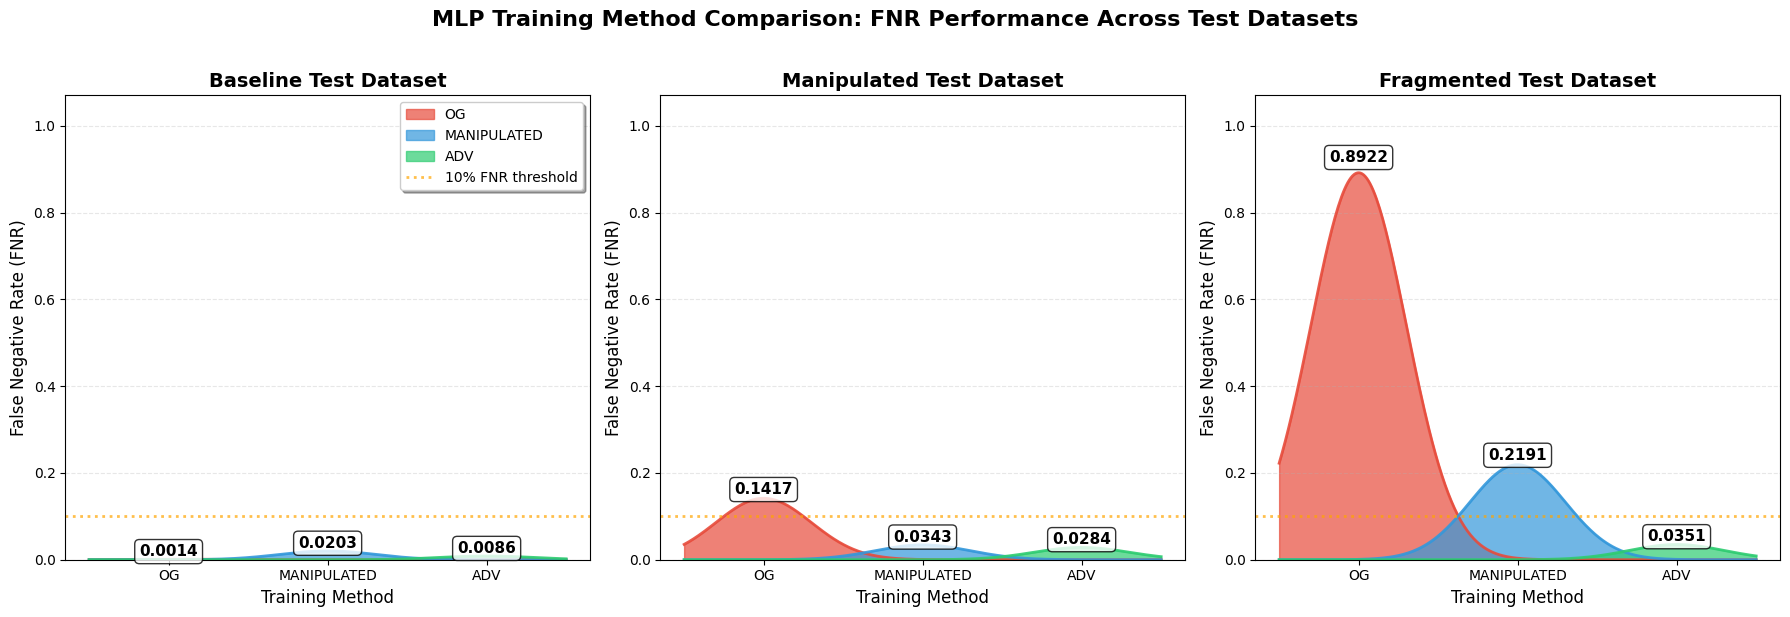

MLP TRAINING METHOD COMPARISON ANALYSIS

FNR Performance Matrix:
                 Baseline  Manipulated  Fragmented
Training_Method                                   
OG                 0.0014       0.1417      0.8922
MANIPULATED        0.0203       0.0343      0.2191
ADV                0.0086       0.0284      0.0351

Performance Improvement vs Original Training (OG):
------------------------------------------------------------

MANIPULATED Training vs OG:
  Baseline:    0.0203 vs 0.0014 (+1350.0%)
  Manipulated: 0.0343 vs 0.1417 (-75.8%)
  Fragmented:  0.2191 vs 0.8922 (-75.4%)

ADV Training vs OG:
  Baseline:    0.0086 vs 0.0014 (+514.3%)
  Manipulated: 0.0284 vs 0.1417 (-80.0%)
  Fragmented:  0.0351 vs 0.8922 (-96.1%)

Best Performing Training Method by Test Dataset:
--------------------------------------------------
Baseline    : OG           (FNR: 0.0014)
Manipulated : ADV          (FNR: 0.0284)
Fragmented  : ADV          (FNR: 0.0351)

Overall Training Method Rankings (Average F

In [1]:
# MLP Training Method Comparison Analysis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the training comparison data  
# Note: Assuming fragmented value for OG is 0.8922 (not 89.22) to keep FNR in 0-1 range
training_data = {
    'Training_Method': ['OG', 'MANIPULATED', 'ADV'],
    'Baseline': [0.0014, 0.0203, 0.0086],
    'Manipulated': [0.1417, 0.0343, 0.0284], 
    'Fragmented': [0.8922, 0.2191, 0.0351]
}

# Create DataFrame
training_df = pd.DataFrame(training_data)

# Set up the plots - 3 separate charts for each test dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('MLP Training Method Comparison: FNR Performance Across Test Datasets', 
             fontsize=16, fontweight='bold', y=1.02)

# Define colors for training methods
training_colors = {'OG': '#e74c3c', 'MANIPULATED': '#3498db', 'ADV': '#2ecc71'}
test_datasets = ['Baseline', 'Manipulated', 'Fragmented']
training_methods = ['OG', 'MANIPULATED', 'ADV']

# Create individual plots for each test dataset using Gaussian style
for i, test_dataset in enumerate(test_datasets):
    ax = axes[i]
    
    # Get FNR values for current test dataset
    fnr_values = training_df[test_dataset].tolist()
    
    # Create smooth Gaussian-style curves for each training method
    x_positions = np.arange(len(training_methods))
    x_smooth = np.linspace(-0.5, len(training_methods)-0.5, 300)
    
    for j, (method, value) in enumerate(zip(training_methods, fnr_values)):
        # Create a Gaussian curve centered at each method position
        width = 0.3  # Width of the Gaussian
        gaussian = value * np.exp(-0.5 * ((x_smooth - j) / width) ** 2)
        
        # Plot the filled curve
        ax.fill_between(x_smooth, 0, gaussian, 
                       color=training_colors[method], alpha=0.7, 
                       label=method if i == 0 else "")
        
        # Plot the smooth line outline
        ax.plot(x_smooth, gaussian, 
               color=training_colors[method], linewidth=2, alpha=0.9)
        
        # Add peak value labels
        ax.text(j, value + value*0.02, f'{value:.4f}', 
               ha='center', va='bottom', fontsize=11, fontweight='bold',
               bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    # Customize each subplot
    ax.set_title(f'{test_dataset} Test Dataset', fontsize=14, fontweight='bold')
    ax.set_ylabel('False Negative Rate (FNR)', fontsize=12)
    ax.set_xlabel('Training Method', fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(training_methods)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Set consistent y-axis limits for better comparison
    ax.set_ylim(0, max(training_df[test_datasets].max()) * 1.2)
    
    # Add horizontal lines to show performance thresholds
    ax.axhline(y=0.1, color='orange', linestyle=':', alpha=0.7, linewidth=2, label='10% FNR threshold')
    if i == 0:  # Only show legend on first plot
        ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

# Create a comprehensive comparison table and analysis
print("="*80)
print("MLP TRAINING METHOD COMPARISON ANALYSIS")
print("="*80)

print("\nFNR Performance Matrix:")
print(training_df.set_index('Training_Method').round(4))

# Calculate improvement percentages compared to OG training
print(f"\nPerformance Improvement vs Original Training (OG):")
print("-" * 60)

og_baseline = training_df[training_df['Training_Method'] == 'OG']['Baseline'].iloc[0]
og_manipulated = training_df[training_df['Training_Method'] == 'OG']['Manipulated'].iloc[0]  
og_fragmented = training_df[training_df['Training_Method'] == 'OG']['Fragmented'].iloc[0]

for method in ['MANIPULATED', 'ADV']:
    method_data = training_df[training_df['Training_Method'] == method]
    
    print(f"\n{method} Training vs OG:")
    
    # Calculate percentage improvements (negative means improvement for FNR)
    baseline_improvement = ((method_data['Baseline'].iloc[0] - og_baseline) / og_baseline * 100) if og_baseline > 0 else 0
    manipulated_improvement = ((method_data['Manipulated'].iloc[0] - og_manipulated) / og_manipulated * 100) if og_manipulated > 0 else 0
    fragmented_improvement = ((method_data['Fragmented'].iloc[0] - og_fragmented) / og_fragmented * 100) if og_fragmented > 0 else 0
    
    print(f"  Baseline:    {method_data['Baseline'].iloc[0]:.4f} vs {og_baseline:.4f} ({baseline_improvement:+.1f}%)")
    print(f"  Manipulated: {method_data['Manipulated'].iloc[0]:.4f} vs {og_manipulated:.4f} ({manipulated_improvement:+.1f}%)")  
    print(f"  Fragmented:  {method_data['Fragmented'].iloc[0]:.4f} vs {og_fragmented:.4f} ({fragmented_improvement:+.1f}%)")

# Best performing method for each test dataset
print(f"\nBest Performing Training Method by Test Dataset:")
print("-" * 50)

for dataset in test_datasets:
    best_idx = training_df[dataset].idxmin()
    best_method = training_df.iloc[best_idx]['Training_Method']
    best_fnr = training_df.iloc[best_idx][dataset]
    print(f"{dataset:12}: {best_method:12} (FNR: {best_fnr:.4f})")

# Calculate average performance across all test datasets
print(f"\nOverall Training Method Rankings (Average FNR):")
print("-" * 50)

training_df['Average_FNR'] = training_df[test_datasets].mean(axis=1)
ranked_methods = training_df.sort_values('Average_FNR')[['Training_Method', 'Average_FNR']]

for i, (_, row) in enumerate(ranked_methods.iterrows(), 1):
    print(f"{i}. {row['Training_Method']:12}: {row['Average_FNR']:.4f}")

# Robustness analysis - standard deviation across test datasets
print(f"\nTraining Method Robustness (Lower std = More Consistent):")
print("-" * 60)

training_df['FNR_Std'] = training_df[test_datasets].std(axis=1)
robustness_ranking = training_df.sort_values('FNR_Std')[['Training_Method', 'FNR_Std']]

for i, (_, row) in enumerate(robustness_ranking.iterrows(), 1):
    print(f"{i}. {row['Training_Method']:12}: std = {row['FNR_Std']:.4f}")

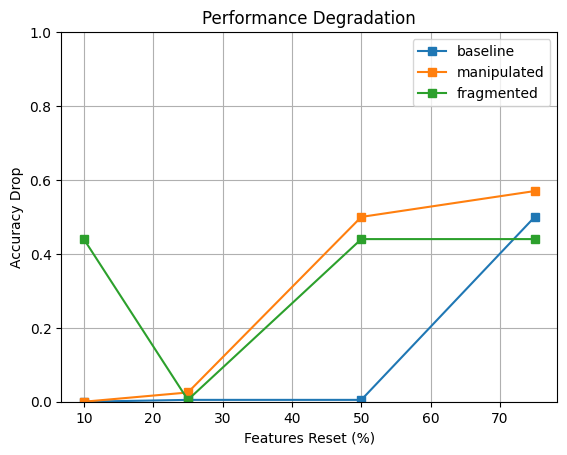

In [1]:
# Recreate the plot with adjusted y-axis scale (0 to 1)

import matplotlib.pyplot as plt

# Data approximated from the provided figure
x = [10, 25, 50, 75]

baseline = [0.0, 0.005, 0.005, 0.50]
manipulated = [0.0, 0.025, 0.50, 0.57]
fragmented = [0.44, 0.005, 0.44, 0.44]

# Create the plot
plt.figure()
plt.plot(x, baseline, marker='s', label='baseline')
plt.plot(x, manipulated, marker='s', label='manipulated')
plt.plot(x, fragmented, marker='s', label='fragmented')

plt.title("Performance Degradation")
plt.xlabel("Features Reset (%)")
plt.ylabel("Accuracy Drop")
plt.ylim(0, 1)  # Adjusted scale from 0 to 1
plt.legend()
plt.grid(True)

plt.show()